In [1]:
from Calibration import *
from Integrate_and_save import *
import tkinter as tk
from tkinter import filedialog, simpledialog
import os
import pyFAI
# pyFAI.use_opencl = False

root = tk.Tk()
root.withdraw()  # Hide the root window
root.attributes("-topmost", True)  # Keep the dialog on top

''

In [2]:
calibrant = 'ito_calibrant.D'
ponifile = 'ITO_test.poni'

giwaxsCalibration(ponifile, calibrant)

Launching pyFAI calibration GUI. This will take a few seconds...


In [16]:
ITO_image_path = filedialog.askopenfilename(
    title="Select the ITO image",
    filetypes=[("All files", "*.*")]
)


K:/printz_Apr2024/MAPI_YL/MAPI_1pct_AVA_S1_30min_18SCFM_ITO_refined.poni
Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.888281e-01 m	PONI= 8.931943e-02, 5.107767e-02 m	rot1=-0.641809  rot2=0.007797  rot3=3.141593 rad
DirectBeamDist= 235.744 mm	Center: x=1117.443, y=529.986 pix	Tilt= 36.775° tiltPlanRotation= 0.746° 𝛌= 1.240Å


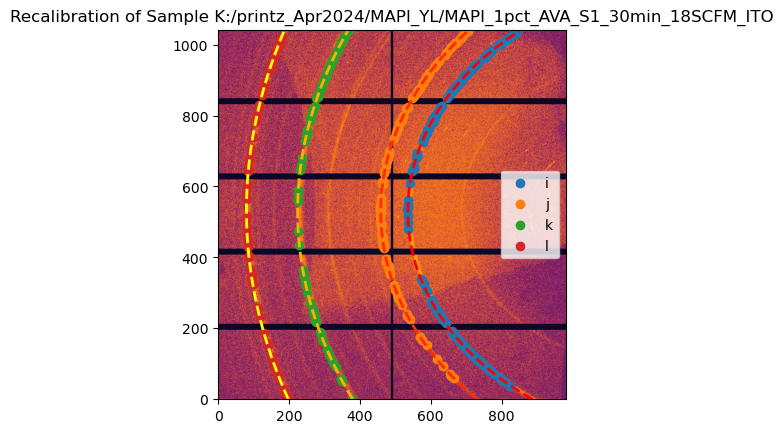

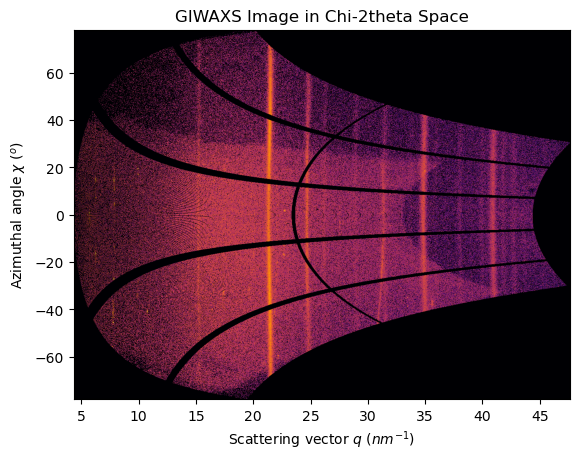

In [17]:
image_path = ITO_image_path
sample_name = image_path.split("\\")[-1].split(".")[0]  # Extract sample name from image path
initial_poni = r"K:\printz_Apr2024\MAPI_YL\MAPI_1pct_AVACl_S1_18_5min\AVACl_S1.poni"
calibrant_file = r"ito_calibrant_refine.D"

if not image_path.endswith(".tif"):
    refined_poni = image_path + "_refined.poni"
else:
    refined_poni = image_path.replace(".tif", "_refined.poni")
print(refined_poni)
refine_calibration(sample_name, image_path, initial_poni, calibrant_file, refined_poni)
plot_Chi_2theta(image_path, refined_poni) #sanity check, the lines should be straight and vertical

In [19]:
folder_path = filedialog.askdirectory(
    title="Select the folder with images to integrate",
    mustexist=True
)
#ask user to select poni file
poni_file = filedialog.askopenfilename(
    title="Select the poni file",
    filetypes=[("PONI files", "*.poni")]
)
# ask user to type sample name
ponifile_basename = os.path.basename(poni_file).split(".")[0]

sample_name = simpledialog.askstring(
    "Sample Name", "Enter the sample name (without spaces):",
    initialvalue=ponifile_basename
) 

Detector Pilatus 1M	 PixelSize= 172µm, 172µm	 BottomRight (3)
Wavelength= 1.239842e-10 m
SampleDetDist= 1.876109e-01 m	PONI= 9.043127e-02, 4.752647e-02 m	rot1=-0.664106  rot2=0.002416  rot3=3.141593 rad
DirectBeamDist= 238.246 mm	Center: x=1130.061, y=529.110 pix	Tilt= 38.051° tiltPlanRotation= 0.225° 𝛌= 1.240Å


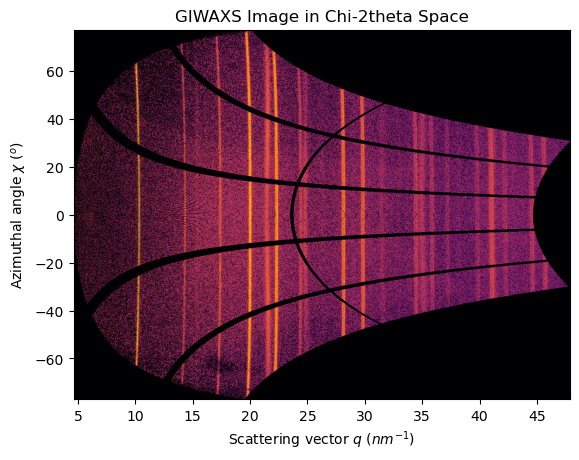

In [20]:
image_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.tif')]
if not image_files:
    raise FileNotFoundError("No .tif images found in the selected folder.")
image_path = os.path.join(folder_path, image_files[300])
plot_Chi_2theta(image_path, poni_file)

In [9]:
from silx.opencl import ocl
ocl

OpenCL devices:
[0] NVIDIA CUDA: (0,0) NVIDIA GeForce RTX 3060

0.18761090919756568


Integrating TIFs: 100%|██████████| 1582/1582 [00:28<00:00, 55.11it/s]


Saved integrated GIWAXS data to K:/printz_Apr2024/MAPI_YL/MAPI_1pct_AVA_S1_18_30min\MAPI_1pct_AVA_S1_18_30min_GIWAXS_raw.npz


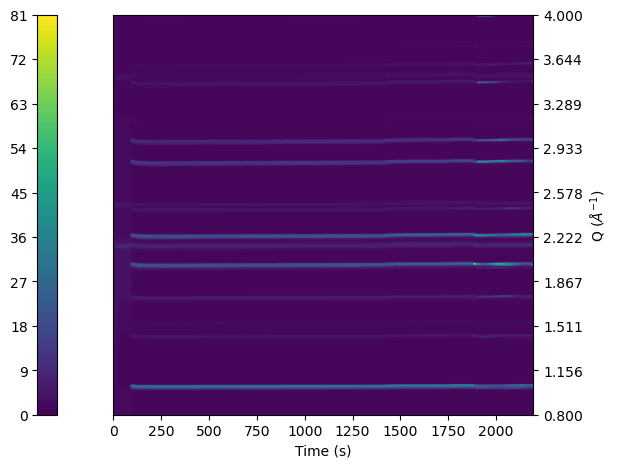

In [21]:

from Integrate_and_save import *
# folder_path  = r'k:\printz_Apr2024\MAPI_YL\MAPI_1pct_AVACl_S1_18_5min'
# # Integrate the refined calibration
method = ("full", "csr", "opencl")
integrated_data = integrate_giwaxs(folder_path, poni_file, method)

# #if you don't have a GPU or don't want to use opencl, you can use the following line instead:
# # integrated_data = integrate_giwaxs(folder_path, poni_file)
# q, t, I = integrated_data
save_and_plot(*integrated_data, folder_path, sample_name)

In [10]:
import glob
def load_GIWAXS_npz(npz_file_folder):
    """
    Load previously saved GIWAXS q, time, intensity arrays from .npz.
    """
    # Find the first .npz file in the folder
    npz_files = glob.glob(os.path.join(npz_file_folder, "*.npz"))
    if not npz_files:
        raise FileNotFoundError(f"No .npz files found in {npz_file_folder}")
    npz_file_path = npz_files[0]
    data = np.load(npz_file_path)
    return data["q"], data["time"], data["intensity"]

q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
print(f"{q}, {time}, {intensity}")
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(intensity.T, aspect='auto', extent=[time[0], time[-1], q[0], q[-1]], origin='lower', cmap='viridis')
plt.colorbar(label='Intensity')
plt.xlabel('Time')
plt.ylabel('q')
plt.title('GIWAXS Intensity Heatmap')
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\M'
<>:14: SyntaxWarning: invalid escape sequence '\M'
C:\Users\raglo\AppData\Local\Temp\ipykernel_30184\581425105.py:14: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
C:\Users\raglo\AppData\Local\Temp\ipykernel_30184\581425105.py:14: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


FileNotFoundError: No .npz files found in K:\MAPbI3_nanofibers_S1\GIWAXS

<>:42: SyntaxWarning: invalid escape sequence '\M'
<>:42: SyntaxWarning: invalid escape sequence '\M'
C:\Users\Aj\AppData\Local\Temp\ipykernel_36368\4047504471.py:42: SyntaxWarning: invalid escape sequence '\M'
  q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")


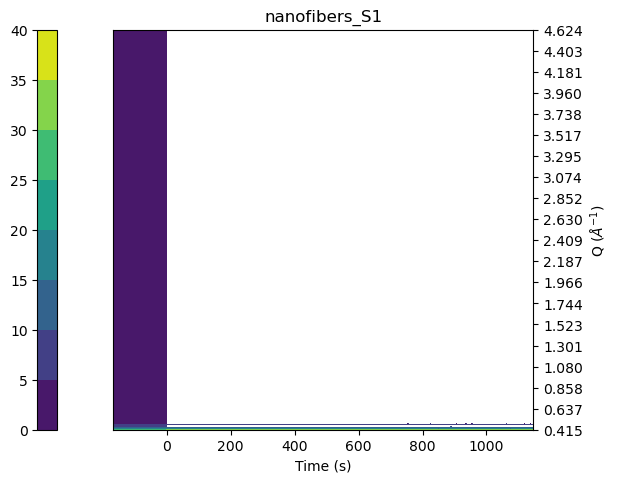

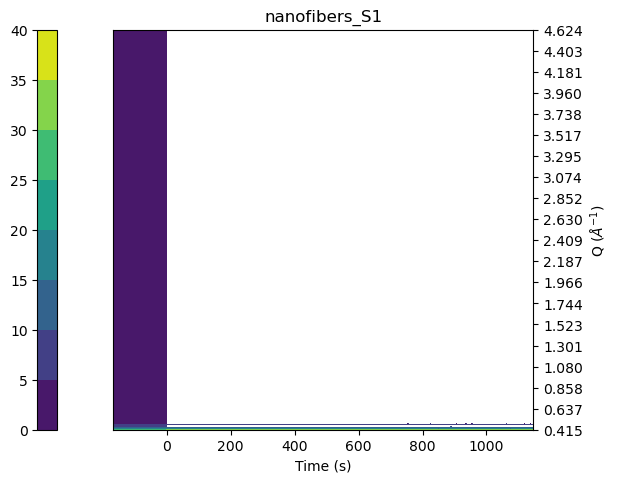

In [ ]:
def plotGIWAXS(sample_name, q, frame_time, intensity):

    '''
    Parameters
    ----------
    sample_name : str,
        name of the sample. Default is the name under which scan is saved.
    save_path : path object
        where the output is saved.


    Returns
    -------
    Contour plot

    '''

    # create an empty figure with the following dimensions
    fig = plt.figure(figsize=(7, 5))
    left, bottom, width, height = 0.1, 0.1, 0.8, 0.8
    ax = fig.add_axes([left, bottom, width, height])

    # add the contour plot and a colorbar
    cp = ax.contourf(frame_time, q, intensity.T)
    plt.colorbar(cp, location='left')

    # define axis names, ticks, etc.
    q_min, q_max = (q[0], q[-1])
    y_ticks = np.linspace(q_min, q_max, 20)  # number of tickmarks
    ax.set_xlabel('Time (s)')
    ax.set_ylabel(r'Q $(\AA^{-1})$')
    ax.set_yticks(y_ticks)
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")
    ax.set_ylim(q_min, q_max)
    ax.set_title(sample_name)
    # plt.show(block=False)
    # plt.pause(1)

    return fig
sample_name = "nanofibers_S1"
q, time, intensity = load_GIWAXS_npz("K:\MAPbI3_nanofibers_S1\GIWAXS")
plotGIWAXS(sample_name, q, time, intensity)

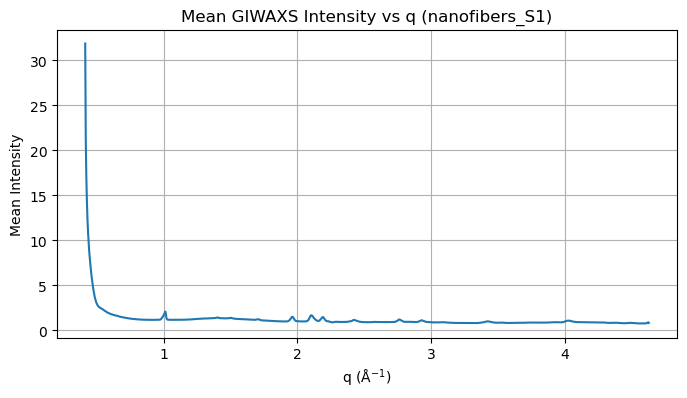

In [10]:
import matplotlib.pyplot as plt

mean_q_profile = np.mean(intensity, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(q, mean_q_profile)
plt.xlabel("q (Å$^{-1}$)")
plt.ylabel("Mean Intensity")
plt.title("Mean GIWAXS Intensity vs q (nanofibers_S1)")
plt.grid(True)
plt.show()


In [6]:
import pyopencl as cl
for i, p in enumerate(cl.get_platforms()):
    for j, d in enumerate(p.get_devices()):
        print(f"[{i},{j}]: {p.name} – {d.name}")


[0,0]: Intel(R) OpenCL Graphics – Intel(R) Iris(R) Xe Graphics
